In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import copy
import numpy as np

In [5]:
from src.utils.normalizer import Normalizer
from typing import Optional, Tuple  

In [ ]:
class Sparse(nn.Module):
    permutations: torch.LongTensor
    def __init__(self, original_weight: torch.Tensor, 
                 N:int = 2, 
                 M:int = 4,
                 n_permutations:int = 10,
                 gamma: float = -0.1,
                 xi:float = 1.1) -> None:
        
        super(Sparse, self).__init__()
        
        self.weight = nn.Parameter(torch.zeros_like(original_weight), requires_grad=True)
        self.sparse_mask = nn.Parameter(torch.zeros_like(original_weight), requires_grad=True)
        self.sparse_mask.data.uniform_(-1, 1)
        
        
        self.register_buffer("permutations", torch.stack([torch.randperm(original_weight.shape[1]) for _ in range(n_permutations)])) 

        
        self.permutation_scales = nn.Parameter(torch.randn(n_permutations, original_weight.shape[1])/n_permutations, requires_grad=True)
        
        self.N = N
        self.M = M
        self.gamma = gamma
        self.xi = xi
        self.n_permutations = n_permutations
        
    def sigmoid(self, x: torch.Tensor) -> torch.Tensor:
        #scaled and clipped sigmoid function
        return torch.clip((self.xi-self.gamma) * torch.sigmoid(x) + self.gamma, 0, 1)
    
    def softmax(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(x, dim=-1)
    
    def calculate_permutation_matrices(self) -> torch.Tensor:
        return self.softmax(self.permutation_matricies)
        
        
    def forward(self) -> torch.Tensor:
        # Apply the sparse mask to the weight
        sparse_weight = self.weight * self.sigmoid(self.sparse_mask)
        # print("Sparse weight shape:", sparse_weight)
        # Apply the permutation matrices and scales
        # print(self.softmax(self.permutation_matricies),self.permutation_scales)
        weight = sparse_weight[:,self.permutations[0]] * self.permutation_scales[0]
        for i in range(1, self.n_permutations):
            weight += sparse_weight[:,self.permutations[i]] * self.permutation_scales[i]
        # weight = torch.einsum("ij,kjl,kl->il",
        #                       sparse_weight,
        #                       self.calculate_permutation_matrices(),    
        #                       self.permutation_scales)
        
        return weight
    
    def binary_penalty_sparse(self, beta: float = 1.0) -> torch.Tensor:
        # Binary penalty for the sparse mask
        # print(torch.abs(2*self.sigmoid(self.permutation_matricies)-1))
        # print(torch.abs(2*self.sigmoid(self.sparse_mask)-1))
        # raise ValueError("Binary penalty is not implemented yet.")
        return torch.mean(1-torch.abs(2*self.sigmoid(self.sparse_mask)-1)**beta)
    
        
    
    def sparsity_penalty(self, l2: bool = True
                         ) -> torch.Tensor:
        # Sparsity penalty for the sparse mask
        if l2:
            return torch.sqrt(torch.mean(torch.square(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N)))
        else:
            return torch.mean(torch.abs(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N))
        
    def get_sparse_mask(self) -> torch.Tensor:
        sparse_mask_soft = self.sigmoid(self.sparse_mask)
        
        sparse_mask_hard = torch.zeros_like(sparse_mask_soft)
        
        #for each M elements in the sparse mask, set the top N elements to 1 and the rest to 0
        idxs = torch.argsort(sparse_mask_soft.view(-1, self.M), dim=1, descending=True)[:, :self.N]
        sparse_mask_hard = sparse_mask_hard.view(-1, self.M).scatter_(1, idxs, 1)
        return sparse_mask_hard.view_as(sparse_mask_soft)
    
    
    def real_weight(self)->torch.Tensor:
        #get the real weight matrix after applying the sparse mask and permutation matrices
        sparse_mask = self.get_sparse_mask()
        sparse_weight = self.weight * sparse_mask
        # print("Sparse weight shape:", sparse_weight)
        # Apply the permutation matrices and scales
        # print(self.softmax(self.permutation_matricies),self.permutation_scales)
        weight = sparse_weight[:,self.permutations[0]] * self.permutation_scales[0]
        for i in range(1, self.n_permutations):
            weight += sparse_weight[:,self.permutations[i]] * self.permutation_scales[i]
        
        return weight
    
        
        
        
        
    
    
        
        

In [11]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/self_attn.q_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )

In [12]:
S = Sparse(original_weight=weight,
                    N=2, 
                    M=4,
                    n_permutations=10,
                    gamma=-0.1,
                    xi=1.1).to(device)

print(S())
# print(S.real_weight())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:7',
       grad_fn=<AddBackward0>)


In [22]:
with torch.no_grad():
    normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])
    normalized_weight = normalized_weight.to(device).detach()
  
#seed to 0 
torch.cuda.manual_seed_all(0)
np.random.seed(0)

S = Sparse(original_weight=normalized_weight.detach().clone(),
                    N=2, 
                    M=4,
                    n_permutations=10,
                    gamma=-0.1,
                    xi=1.1).to(device)

optim = torch.optim.Adam(S.parameters(), lr=1e-1)   

n_iters = 1000

betas_sparse = np.linspace(3.0, 1.0, n_iters)
# np.concat([np.linspace(9.0, 0.0, n_iters//10), np.linspace(0.0,9.0, n_iters//10)]*5)*np.linspace(1.0, 0.1, n_iters) + 1.0
# raise ValueError("betas_sparse:", betas_sparse)

# print("betas_permutation:", betas_permutation)
# raise ValueError("betas_sparse:", betas_sparse)
lambda_binary_sparse, lambda_sparsity = 0.1,0.1
recon_loss_scaling = 1e+1

for i in tqdm.tqdm(range(n_iters)):
    
    optim.zero_grad()
    
    # Forward pass
    sparse_weight = S()
    # print("beta:", betas[i])
    sparse_binary = S.binary_penalty_sparse(beta=betas_sparse[i])
    
    sparsity_penalty = S.sparsity_penalty(l2=False)
    
    # Compute the loss
    recon_loss = torch.mean((sparse_weight - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))
    # loss = binary_penalty * lambda_binary 
    loss = (sparse_binary * lambda_binary_sparse +
            sparsity_penalty * lambda_sparsity) + recon_loss*recon_loss_scaling
    
    # loss = recon_loss*recon_loss_scaling
    
    # Backward pass
    loss.backward()
    optim.step()
    if i % 10 == 0:
      real_reconstruction = S.real_weight()
      real_reconstruction_loss = torch.mean((real_reconstruction - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))
      print(f"Iteration {i}, Loss: {loss.item()}, "
            f"Sparse Binary Penalty: {sparse_binary.item()}, "
            # f"Permutation Binary Penalty: {permutation_binary.item()}, "
            f"Sparsity Penalty: {sparsity_penalty.item()}, "
            # f"Permutation Penalty: {permutation_penalty.item()}, "
            f"Reconstruction Loss: {recon_loss.item()}, "
            f"Real Reconstruction Loss: {real_reconstruction_loss.item()}"
                )
    
    

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 5/1000 [00:00<00:44, 22.17it/s]

Iteration 0, Loss: 0.12216043472290039, Sparse Binary Penalty: 0.9539129137992859, Sparsity Penalty: 0.2671954035758972, Reconstruction Loss: 4.959756552125327e-06, Real Reconstruction Loss: 2.5112526600423735e-06


  2%|▏         | 15/1000 [00:01<01:24, 11.71it/s]

Iteration 10, Loss: 0.1015472263097763, Sparse Binary Penalty: 0.9533001184463501, Sparsity Penalty: 0.06213272362947464, Reconstruction Loss: 3.939898078897386e-07, Real Reconstruction Loss: 1.337897515441e-06


...

 98%|█████████▊| 985/1000 [01:39<00:01, 11.09it/s]

Iteration 980, Loss: 2.620309089707007e-07, Sparse Binary Penalty: 3.321494901342703e-08, Sparsity Penalty: 1.0193161870120093e-09, Reconstruction Loss: 2.586074998589538e-08, Real Reconstruction Loss: 2.7385137713054064e-08


100%|█████████▉| 995/1000 [01:40<00:00, 11.09it/s]

Iteration 990, Loss: 2.608065017284389e-07, Sparse Binary Penalty: 3.268105785991793e-08, Sparsity Penalty: 5.623235210805433e-10, Reconstruction Loss: 2.5748214227405697e-08, Real Reconstruction Loss: 2.7233317823061043e-08


100%|██████████| 1000/1000 [01:41<00:00,  9.86it/s]


In [23]:
S.permutation_scales

Parameter containing:
tensor([[-0.4820, -0.1389,  0.0197,  ...,  0.0546,  0.1916,  0.0228],
        [ 0.5457, -0.0699, -0.0548,  ..., -0.1999, -0.0452, -0.0025],
        [ 0.0116,  0.0305,  0.0533,  ...,  0.0951,  0.2856,  0.1145],
        ...,
        [-0.6514, -0.1696,  0.0876,  ...,  0.0751,  0.0804,  0.0976],
        [-0.0280,  0.0994, -0.0885,  ..., -0.1822,  0.1780,  0.1069],
        [-0.2393,  0.4336, -0.1130,  ...,  0.1389,  0.1240, -0.1028]],
       device='cuda:7', requires_grad=True)

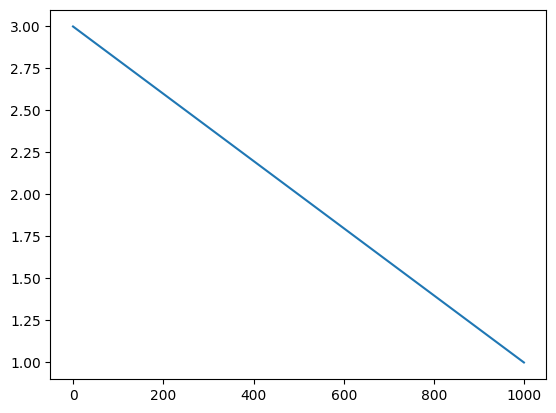

In [31]:
import matplotlib.pyplot as plt
plt.plot(betas_sparse)


In [32]:
S.sigmoid(S.sparse_mask).view(-1, S.M)

tensor([[0., 1., 0., 1.],
        [1., 0., 0., 1.],
        [1., 1., 0., 0.],
        ...,
        [1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.]], device='cuda:7', grad_fn=<ViewBackward0>)

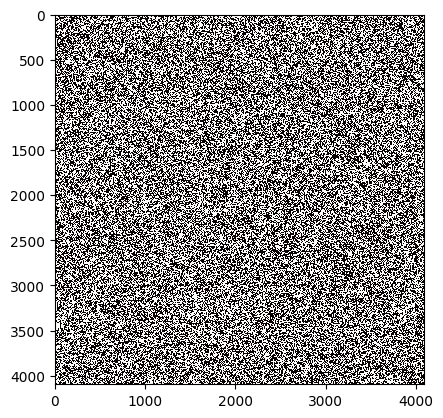

In [33]:
import matplotlib.pyplot as plt
plt.imshow(S.sigmoid(S.sparse_mask).detach().cpu().numpy(), cmap='hot', interpolation='nearest')

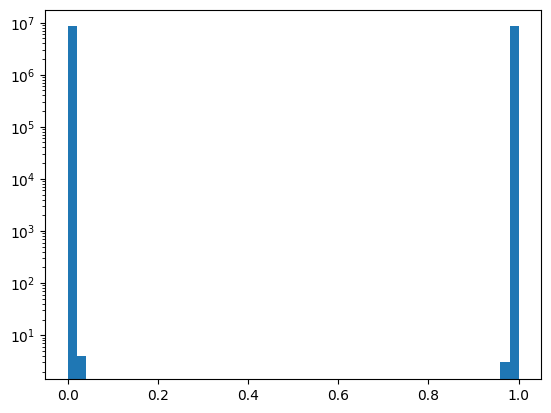

In [34]:
plt.hist(S.sigmoid(S.sparse_mask).detach().cpu().numpy().flatten(), bins=50)
plt.yscale('log')

In [35]:
F.mse_loss(S(),S.real_weight())

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 7 has a total capacity of 47.54 GiB of which 62.38 MiB is free. Process 2940158 has 14.34 GiB memory in use. Process 2979675 has 25.06 GiB memory in use. Including non-PyTorch memory, this process has 8.05 GiB memory in use. Of the allocated memory 7.75 GiB is allocated by PyTorch, and 2.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
S.real_weight()

tensor([[-0.0107, -0.0084, -0.0075,  ..., -0.0030,  0.0058, -0.0036],
        [ 0.0140, -0.0045, -0.0009,  ..., -0.0061, -0.0081,  0.0040],
        [-0.0148,  0.0065,  0.0020,  ...,  0.0063,  0.0108,  0.0014],
        ...,
        [ 0.0006,  0.0067, -0.0006,  ..., -0.0011, -0.0037,  0.0012],
        [ 0.0113, -0.0099, -0.0024,  ..., -0.0084,  0.0021, -0.0034],
        [-0.0117,  0.0008,  0.0024,  ...,  0.0003,  0.0115, -0.0012]],
       device='cuda:7', grad_fn=<AddBackward0>)

In [ ]:
normalized_weight

tensor([[-0.0094, -0.0305, -0.0116,  ...,  0.0112,  0.0041, -0.0108],
        [ 0.0138, -0.0057,  0.0093,  ..., -0.0149, -0.0176,  0.0144],
        [-0.0153,  0.0179,  0.0016,  ...,  0.0108,  0.0313, -0.0064],
        ...,
        [ 0.0008,  0.0088, -0.0007,  ...,  0.0096, -0.0283,  0.0114],
        [ 0.0155,  0.0083,  0.0067,  ..., -0.0333, -0.0150, -0.0146],
        [-0.0110, -0.0073,  0.0052,  ...,  0.0244,  0.0217, -0.0133]],
       device='cuda:7')

In [36]:
#try just standard naive pruning
importances = normalized_weight**2 * hessian_diag.unsqueeze(0)
# torch.abs(weight)  # Example importance scores based on absolute values of weights

idxs = torch.argsort(importances.view(-1, S.M), dim=1, descending=True)[:, :S.N]
sparse_mask_hard = torch.zeros_like(importances)
sparse_mask_hard = sparse_mask_hard.view(-1, S.M).scatter_(1, idxs, 1)
sparse_mask_hard = sparse_mask_hard.view_as(importances)
# Apply the sparse mask to the weight
sparse_weight = normalized_weight * sparse_mask_hard

#get the mse
recon_loss_naive = torch.mean((sparse_weight - normalized_weight) ** 2 * hessian_diag.unsqueeze(0))
print(f"Naive Reconstruction Loss: {recon_loss_naive.item()}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 7 has a total capacity of 47.54 GiB of which 62.38 MiB is free. Process 2940158 has 14.34 GiB memory in use. Process 2979675 has 25.06 GiB memory in use. Including non-PyTorch memory, this process has 8.05 GiB memory in use. Of the allocated memory 7.75 GiB is allocated by PyTorch, and 2.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [37]:
print("our method reconstruction loss:", recon_loss.item())

our method reconstruction loss: 2.5620234822554266e-08
